Dataset taken from https://www.pippanorris.com/data  
Experiment proposed by Simon Rudkin, https://www.swansea.ac.uk/staff/som/academic-staff/s.t.rudkin/  
This notebook was prepared by Davide Gurnari. 

In [1]:
import pandas as pd

from matplotlib import pyplot as plt

In [2]:
full_df = pd.read_csv("data/brexitdata", sep="\t", encoding="iso-8859-1")
print(full_df.shape)
full_df.head()

(631, 391)


,pano,ONSConstID,ConstituencyName,Country,Region,ConstituencyType,Winner17,Con17,Lab17,LD17,...,nore,york,east,west,eeng,wale,lond,swes,swee,pt
0,1,W07000049,Aberavon,Wales,Wales,County,Labour,17.737766,68.119514,1.800529,...,0,0,0,0,0,1,0,0,0,1
1,2,W07000058,Aberconwy,Wales,Wales,County,Conservative,44.594090,42.618974,2.926905,...,0,0,0,0,0,1,0,0,0,2
2,3,S14000001,Aberdeen North,Scotland,Scotland,Borough,Scottish National Party,22.692276,30.010610,4.605925,...,0,0,0,0,0,0,0,0,0,3
3,4,S14000002,Aberdeen South,Scotland,Scotland,Borough,Conservative,42.132470,20.549300,5.866091,...,0,0,0,0,0,0,0,0,0,4
4,5,S14000058,West Aberdeenshire and Kincardine,Scotland,Scotland,County,Conservative,47.852785,11.052785,8.641162,...,0,0,0,0,0,0,0,0,0,5


In this whole example we use the simplified socio-economical data gathering information about housing, relationship, number of cars, profession, self assessed health as well as the level of deprivation of the area the constituancy is located.

In [3]:
subset = [
    "c11HouseOutright",
    "c11HouseMortgage",
    "c11HouseholdOnePerson",
    "c11HouseholdMarried",
    "c11CarsNone",
    "c11CarsOne",
    "c11CarsTwo",
    "c11NSSECLowerManager",
    "c11QualNone",
    "c11QualLevel4",
    "c11HealthVeryGood",
    "c11HealthGood",
    "c11DeprivedNone",
    "c11Deprived1",
]

db104 = full_df[subset].copy()

coloring_subset = ["leaveHanretty", "lm17", "cm17"]
coloring_df = full_df[coloring_subset].copy()

## Create Ball Mapper

In [ ]:
# from pyballmapper import BallMapper

In [ ]:
# Create Ball Mapper graph using random landmark selection

bm = BallMapper(
    X=db104.to_numpy(),  # the pointcloud, as a numpy array
    eps=18, # the radius of the balls
    column_names=subset  # optional: names of the columns in the pointcloud
)  

In [ ]:
# Create Ball Mapper graph using nearest neighbor landmark selection

bm_nearest = BallMapper(
    X=db104.to_numpy(),  # the pointcloud, as a numpy array
    eps=18, # the radius of the balls
    method="nearest",  # use the nearest uncovered point based landmark selection
    column_names=subset  # optional: names of the columns in the pointcloud
)  

## Coloring

In [9]:
from matplotlib import colormaps as cm

my_rainbow_palette = cm.get_cmap("plasma")

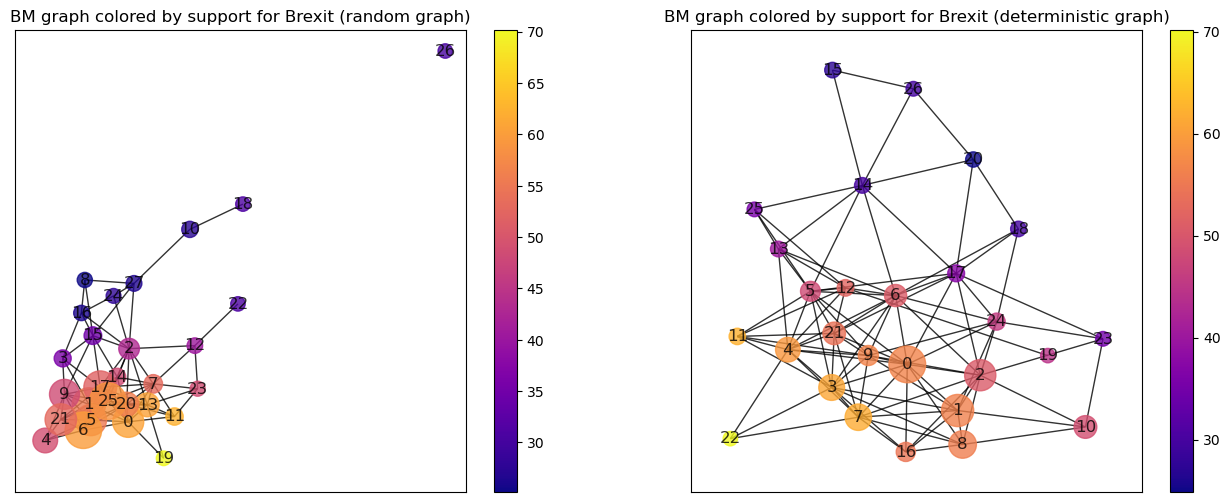

In [10]:
# two bm plots side by side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# first plot on ax1
plt.sca(ax1)
bm.add_coloring(coloring_df)
bm.draw_networkx(
    coloring_variable="leaveHanretty", color_palette=my_rainbow_palette, colorbar=True
)
plt.title("BM graph colored by support for Brexit (random graph)")

plt.sca(ax2)
bm_nearest.add_coloring(coloring_df)
bm_nearest.draw_networkx(
    coloring_variable="leaveHanretty", color_palette=my_rainbow_palette, colorbar=True
)

plt.title("BM graph colored by support for Brexit (deterministic graph)")
plt.savefig("brexit_bm_comparison.pdf")
plt.show()